In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import os
os.environ["LOKY_MAX_CPU_COUNT"] = "8"

## Data Exploration

In [2]:
df = pd.read_excel("data/online_retail_II.xlsx", sheet_name=0)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [4]:
df.isna().sum()    

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

Notice that the dataframe consists of 52461 entries but Customer ID has 417534 non-null data, which raises concern to investigate null values

In [5]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


The above table shows that some price values are negative, which should not happen

In [6]:
df.describe(include='O')

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [7]:
# investigate rows with null Customer IDs
df[df['Customer ID'].isna()].head(15)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


From the table above it may seems we can assume that null Customer IDs are associated with Price of 0.00 and negative values of Quantity, but is that always the case?

In [8]:
df[df['Quantity'] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


A pattern can be seen which is that negative quantities are associated with Invoice starting with the letter 'C', in which the dataset documentation states "**InvoiceNo: Invoice number. Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation.**"

In [9]:
# to investigate, we check using regex which records have an Invoice code that is not length 6
df["Invoice"] = df["Invoice"].astype("str")
df[df["Invoice"].str.match("^\\d{6}$") == False]



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.0,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.0,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.0,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.0,United Kingdom


In [10]:
# check the prefix of non-6-length Invoices
prefixes = df["Invoice"].str.replace("[0-9]", "", regex=True).unique()
prefixes

array(['', 'C', 'A'], dtype=object)

In [11]:
df[df["Invoice"].str.startswith("A")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


It can be seen that another prefix is present in Invoice, 'A', which are adjustments, manual corrections the business makes to their accounts that aren't normal customer sales. These records contribute to the negative prices.  
The dataset documentation also states "**StockCode: Product (item) code. Nominal, a 5-digit integral number uniquely assigned to each distinct product.**", in which adjustmens have StockCode of a single letter. This raises motivation to further investigate StockCode

In [12]:
df["StockCode"] = df["StockCode"].astype("str")
df[(df["StockCode"].str.match("^\\d{5}$") == False) & (df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == False)]["StockCode"].unique()

array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE'],
      dtype=object)

### Codes to Remove

| StockCode | What it is | Why it should be removed |
|---|---|---|
| `POST` | Postage charge | A shipping fee, inflates Monetary without any merchandise |
| `DOT` | DOTCOM postage | Online-order postage fee, service charge |
| `C2` | Carriage | Delivery/carriage cost, operational fee |
| `M` / `m` | Manual entry | Ad-hoc manual line items with no real product, arbitrary values pollute RFM |
| `D` | Discount | Negative-value adjustment, not a purchase, distorts Monetary downward |
| `BANK CHARGES` | Bank fees | Financial/admin cost, unrelated to customer buying behavior |
| `AMAZONFEE` | Amazon marketplace fee | Platform fee with large skewing values |
| `CRUK` | Cancer Research UK donation | A charity donation, not a product sale |
| `S` | Samples | Free/sample stock, not a genuine revenue transaction |
| `B` | Adjust bad debt | Accounting write-off with large negatives will distorts Monetary |
| `ADJUST` / `ADJUST2` | Manual stock adjustments | Inventory corrections, not customer purchases |
| `TEST001` / `TEST002` | Test transactions | Dummy/QA entries |
| `gift_0001_XX` | Gift card top-ups | Stored-value loads, not product purchases |
| `PADS` | "PADS to match all cushions" | Borderline real product with a non-standard code, few rows, safe to drop or keep |


In [13]:
df['Country'].unique()

array(['United Kingdom', 'France', 'USA', 'Belgium', 'Australia', 'EIRE',
       'Germany', 'Portugal', 'Japan', 'Denmark', 'Nigeria',
       'Netherlands', 'Poland', 'Spain', 'Channel Islands', 'Italy',
       'Cyprus', 'Greece', 'Norway', 'Austria', 'Sweden',
       'United Arab Emirates', 'Finland', 'Switzerland', 'Unspecified',
       'Malta', 'Bahrain', 'RSA', 'Bermuda', 'Hong Kong', 'Singapore',
       'Thailand', 'Israel', 'Lithuania', 'West Indies', 'Lebanon',
       'Korea', 'Brazil', 'Canada', 'Iceland'], dtype=object)

In [14]:
(df["Country"] != "United Kingdom").sum()

np.int64(39609)

### Data Exploration Findings

The raw dataset (sheet 0) contains **525,461 transactions** across 8 columns, covering Dec 2009 – Dec 2010. Exploration surfaced several data-quality issues that must be addressed before building RFM features:

| # | Finding | Evidence | Impact on RFM |
|---|---------|----------|---------------|
| 1 | **Missing Customer IDs** | 107,927 rows (~20.5%) have null `Customer ID` |Rows with no ID cannot be attributed and must be dropped |
| 2 | **Missing Descriptions** | 2,928 null `Description` values | Mostly tied to the junk/adjustment rows, this will be resolved once those are removed |
| 3 | **Negative quantities** | `Quantity` min = -9,600 | Caused by cancellations (Invoice prefix `C`, ~10,206 rows). |
| 4 | **Negative prices** | `Price` min = -53,594 | Caused by adjustments (Invoice prefix `A`, 3 rows of "Adjust bad debt") |
| 5 | **Invoice prefixes** | Distinct prefixes: `''` (normal), `'C'` (cancellation), `'A'` (adjustment) | Only plain 6-digit invoices (`^\d{6}$`) are real sales |
| 6 | **Non-product StockCodes** | `POST`, `DOT`, `C2`, `C3`, `M`/`m`, `D`, `S`, `B`, `BANK CHARGES`, `AMAZONFEE`, `ADJUST`/`ADJUST2`, `TEST001/002`, `gift_0001_XX`, `GIFT`, `SP1002`, `PADS`, `DCGS...`  | These are fees, samples, tests, and adjustments that will inflate/distort Monetary & Frequency |
| 7 | **Whitespace in StockCode** | `'47503J '` has a trailing space | Valid code but  must strip whitespace first or it gets wrongly dropped |
| 8 | **International orders** | 40 countries; 39,609 rows (~7.5%) are non-UK, includes `Unspecified` | Country does not enter the clustering math (RFM only), so a keeping will not harm |


## Data Cleaning

In [15]:
# strip whitespace first
df["StockCode"] = df["StockCode"].astype("str").str.strip()
df["Invoice"] = df["Invoice"].astype("str")

mask = (
    df["Customer ID"].notna() # must have a customer
    & (df["Invoice"].str.match("^\\d{6}$")) # drops C and A prefixes
    & (df["StockCode"].str.match("^\\d{5}[a-zA-Z]*$")) # product codes only (drops POST, DOT, DCGS..., gift_, etc.)
    & (df["Quantity"] > 0) # no returns / zero lines
    & (df["Price"] > 0) # no free / negatives
)

clean_df = df[mask].copy()
clean_df = clean_df.drop_duplicates()
print(f"{len(df):,} rows -> {len(clean_df):,} rows ({len(clean_df)/len(df):.1%} kept)")


525,461 rows -> 399,552 rows (76.0% kept)


In [16]:
clean_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Feature Engineering

In [17]:
clean_df["TotalSales"] = clean_df["Quantity"] * clean_df["Price"]
clean_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [18]:
agg_df = clean_df.groupby(by="Customer ID", as_index=False).agg(
    MonetaryValue = ("TotalSales", "sum"),
    Frequency = ("Invoice", "nunique"),
    LastInvoiceDate = ("InvoiceDate", "max")
)

agg_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.0,169.36,2,2010-06-28 13:53:00
1,12347.0,1323.32,2,2010-12-07 14:57:00
2,12348.0,221.16,1,2010-09-27 14:59:00
3,12349.0,2221.14,2,2010-10-28 08:23:00
4,12351.0,300.93,1,2010-11-29 15:23:00


In [19]:
max_invoice_date = agg_df["LastInvoiceDate"].max()

agg_df["Recency"] = (max_invoice_date - agg_df["LastInvoiceDate"]).dt.days

agg_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,169.36,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10


In [20]:
agg_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,4285.000000,4285.000000,4285.000000,4285,4285.000000
mean,15356.806768,2016.252614,4.426138,2010-09-11 00:06:10.431738624,89.548191
min,12346.000000,1.550000,1.000000,2009-12-01 10:49:00,0.000000
25%,13891.000000,306.640000,1.000000,2010-07-27 14:39:00,17.000000
50%,15362.000000,692.240000,2.000000,2010-10-19 12:10:00,51.000000
75%,16840.000000,1699.250000,5.000000,2010-11-22 11:24:00,135.000000
max,18287.000000,349164.350000,183.000000,2010-12-09 20:01:00,373.000000
std,1699.839258,8811.212134,7.938017,NaN,96.359872


### Visualizations

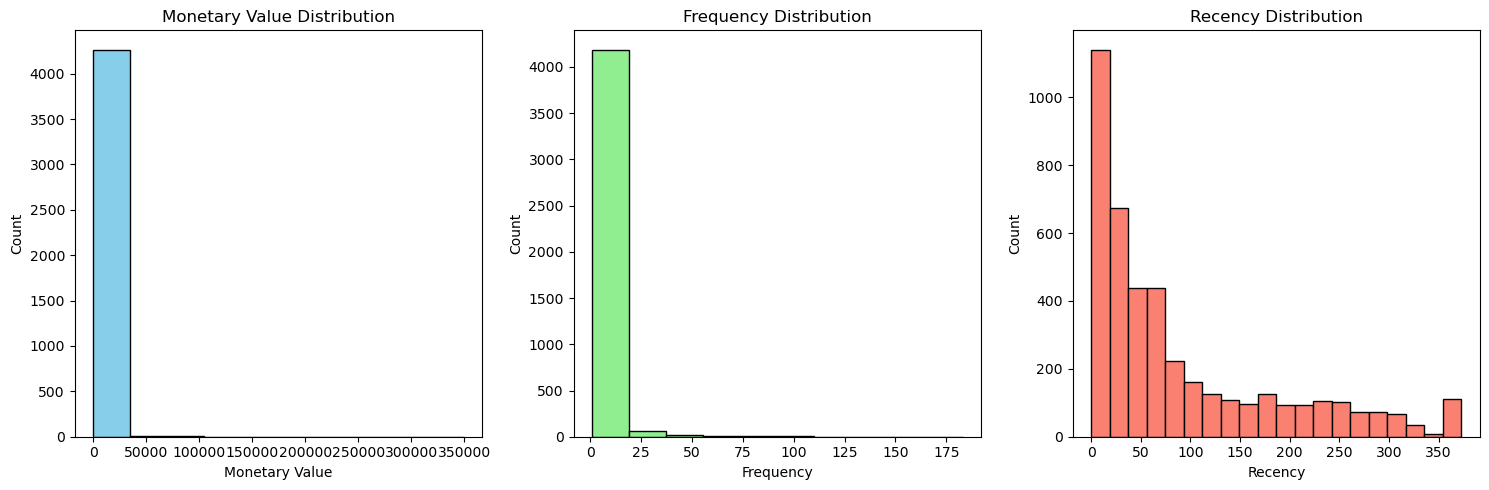

In [21]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(agg_df['MonetaryValue'], bins=10, color='skyblue', edgecolor='black')
plt.title('Monetary Value Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
plt.hist(agg_df['Frequency'], bins=10, color='lightgreen', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
plt.hist(agg_df['Recency'], bins=20, color='salmon', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Recency')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

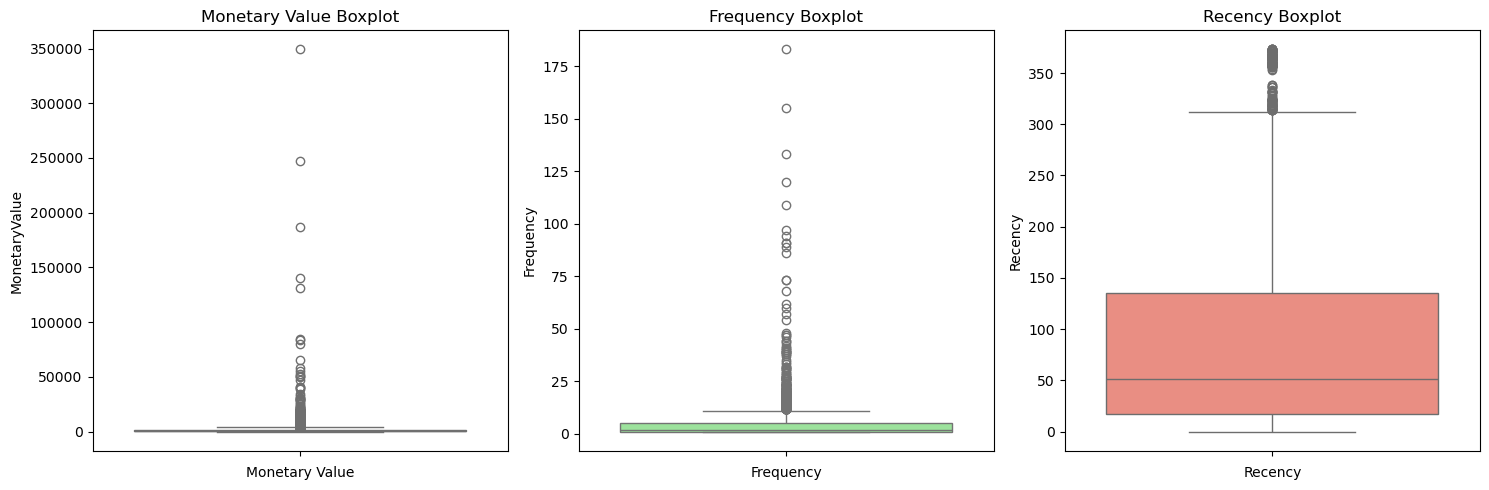

In [22]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=agg_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=agg_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=agg_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

- Monetary & Frequency: mean is 3–4× the median, std exceeds the mean, skew is huge, and max is hundreds of times the median.
- Recency: mean and median are much closer, skew is mild, and it's bounded at 373 (the dataset's time span). Nearly well-behaved.

It is important to investigate outliers before keeping or removing them because they represent customers that have spent a lot & very frequently, hence are the most valuable customers. The outliers are therefore separated below purely to profile them, before deciding how to handle them (see the log-transformation decision further down).

In [23]:
M_Q1 = agg_df["MonetaryValue"].quantile(0.25)
M_Q3 = agg_df["MonetaryValue"].quantile(0.75)
M_IQR = M_Q3 - M_Q1
m_outliers_df = agg_df[
    (agg_df["MonetaryValue"] > (M_Q3 + 1.5 * M_IQR))
    | (agg_df["MonetaryValue"] < (M_Q1 - 1.5 * M_IQR))
].copy()

m_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,421.000000,421.000000,421.000000,421,421.000000
mean,15079.767221,12198.205653,17.161520,2010-11-09 13:16:23.087886080,30.000000
min,12357.000000,3788.210000,1.000000,2009-12-10 18:03:00,0.000000
25%,13599.000000,4590.530000,8.000000,2010-11-08 14:14:00,3.000000
50%,14936.000000,6171.070000,12.000000,2010-11-26 12:19:00,13.000000
75%,16656.000000,10300.980000,18.000000,2010-12-06 10:03:00,31.000000
max,18260.000000,349164.350000,183.000000,2010-12-09 19:32:00,364.000000
std,1723.920744,25886.947520,19.765351,NaN,51.606109


In [24]:
F_Q1 = agg_df["Frequency"].quantile(0.25)
F_Q3 = agg_df["Frequency"].quantile(0.75)
F_IQR = F_Q3 - F_Q1
f_outliers_df = agg_df[
    (agg_df["Frequency"] > (F_Q3 + 1.5 * F_IQR))
    | (agg_df["Frequency"] < (F_Q1 - 1.5 * F_IQR))
].copy()

f_outliers_df.describe()


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,279.000000,279.000000,279.000000,279,279.000000
mean,15352.655914,14374.117993,23.810036,2010-11-23 11:06:20.645161216,16.089606
min,12437.000000,1091.440000,12.000000,2010-05-12 16:51:00,0.000000
25%,13800.000000,4328.435000,13.000000,2010-11-20 13:14:30,2.000000
50%,15465.000000,6615.770000,17.000000,2010-12-02 10:46:00,7.000000
75%,16828.500000,11652.410000,23.000000,2010-12-07 11:08:30,19.000000
max,18260.000000,349164.350000,183.000000,2010-12-09 19:32:00,211.000000
std,1748.429987,31383.976464,21.932937,NaN,26.589117


In [25]:
non_outliers_df = agg_df[(~agg_df.index.isin(m_outliers_df.index)) & (~agg_df.index.isin(f_outliers_df.index))]
non_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3810.000000,3810.000000,3810.000000,3810,3810.000000
mean,15378.286089,880.964265,2.865092,2010-09-03 11:26:19.795275776,97.075591
min,12346.000000,1.550000,1.000000,2009-12-01 10:49:00,0.000000
25%,13913.500000,277.400000,1.000000,2010-07-08 15:37:30,22.000000
50%,15390.500000,581.125000,2.000000,2010-10-12 16:05:30,58.000000
75%,16856.750000,1256.622500,4.000000,2010-11-17 13:14:00,154.000000
max,18287.000000,3786.700000,11.000000,2010-12-09 20:01:00,373.000000
std,1693.112036,815.589926,2.245889,NaN,98.099456


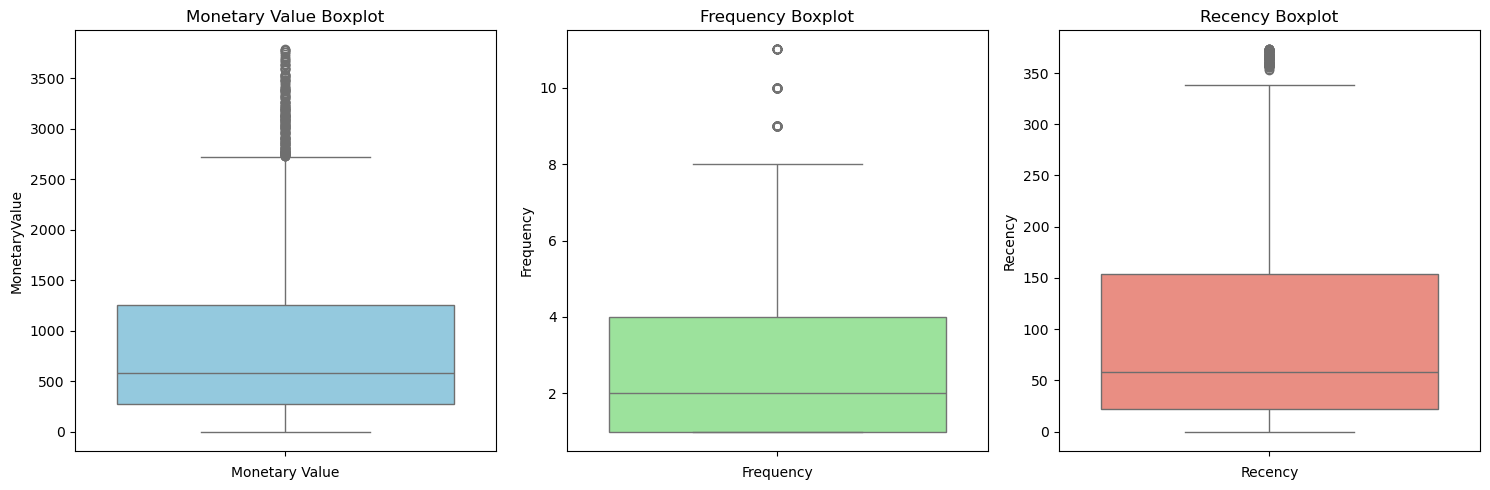

In [26]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=non_outliers_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=non_outliers_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=non_outliers_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()



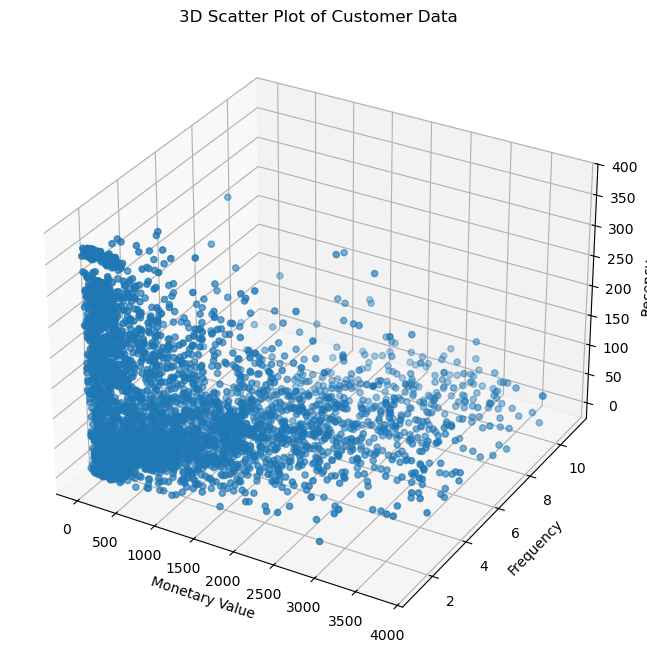

In [27]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(non_outliers_df["MonetaryValue"], non_outliers_df["Frequency"], non_outliers_df["Recency"])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data')

plt.show()

### Handling Skew

The IQR analysis above shows the "outliers" are not data errors but rather are the business's most valuable customers (high Monetary, high Frequency, recent purchases). Removing them would discard exactly the VIP segment that customer segmentation is meant to surface, so keeping all customers is not an unreaasonable approach.

To still satisfy K-Means' need for comparable, roughly symmetric features, log-transform will be used with the RFM values.

After log-transforming, StandardScaler is used such that Recency, Frequency and Monetary each contribute equally to the Euclidean distance K-Means relies on.


In [28]:
rfm = agg_df[["MonetaryValue", "Frequency", "Recency"]]

# log1p compresses the right-skew while keeping all customers (log1p safely handles zeros)
rfm_log = np.log1p(rfm)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(rfm_log)
scaled_data

array([[-1.14835374, -0.39257333,  0.94797036],
       [ 0.45810701, -0.39257333, -1.93717474],
       [-0.94038515, -0.98147241,  0.37064346],
       ...,
       [-0.52403408, -0.98147241,  1.36872877],
       [ 0.41125157, -0.39257333,  0.66902184],
       [ 0.88940624,  0.34935176, -0.64716819]], shape=(4285, 3))

In [29]:
scaled_data_df = pd.DataFrame(
    scaled_data,
    index=agg_df.index,
    columns=("MonetaryValue", "Frequency", "Recency"),
)
scaled_data_df


,MonetaryValue,Frequency,Recency
0,-1.148354,-0.392573,0.947970
1,0.458107,-0.392573,-1.937175
2,-0.940385,-0.981472,0.370643
3,0.863550,-0.392573,-0.020201
4,-0.700053,-0.981472,-1.001735
...,...,...,...
4280,-0.135942,0.838045,-0.647168
4281,-0.455272,-0.981472,0.299099
4282,-0.524034,-0.981472,1.368729
4283,0.411252,-0.392573,0.669022


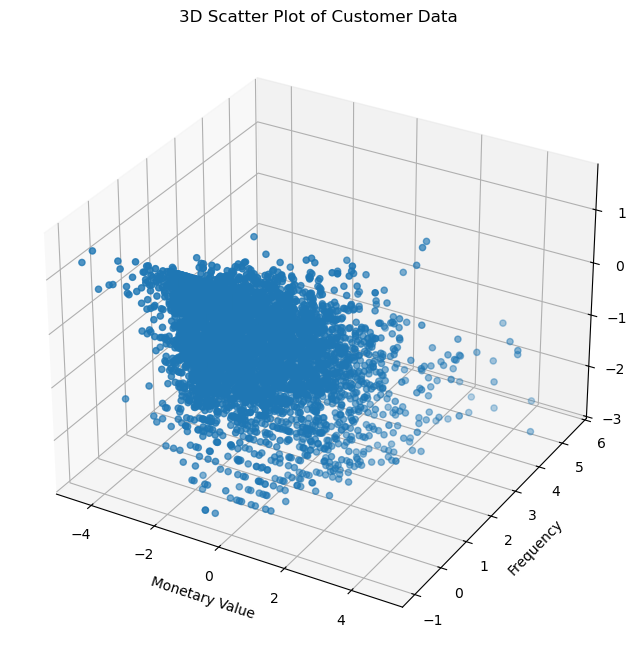

In [30]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(scaled_data_df["MonetaryValue"], scaled_data_df["Frequency"], scaled_data_df["Recency"])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data')

plt.show()



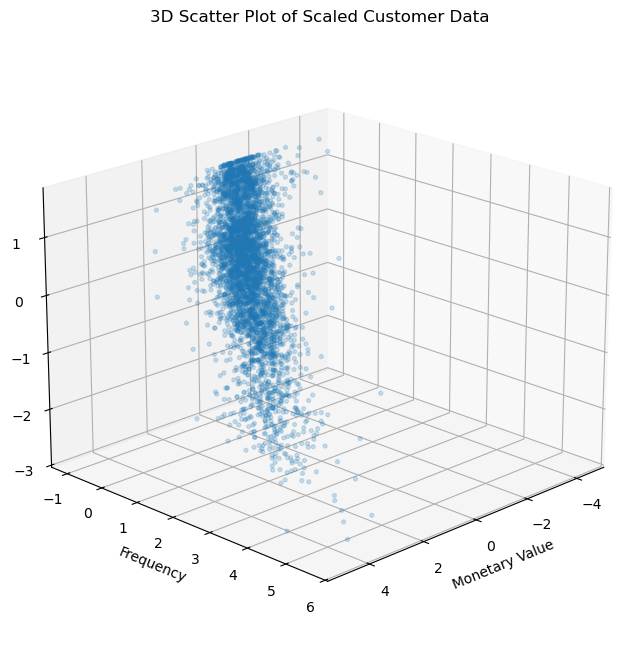

In [31]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    scaled_data_df["MonetaryValue"],
    scaled_data_df["Frequency"],
    scaled_data_df["Recency"],
    alpha=0.2, s=8,
)
ax.view_init(elev=20, azim=45)

ax.set_xlabel("Monetary Value")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
ax.set_title("3D Scatter Plot of Scaled Customer Data")

plt.show()


## Applying KMeans

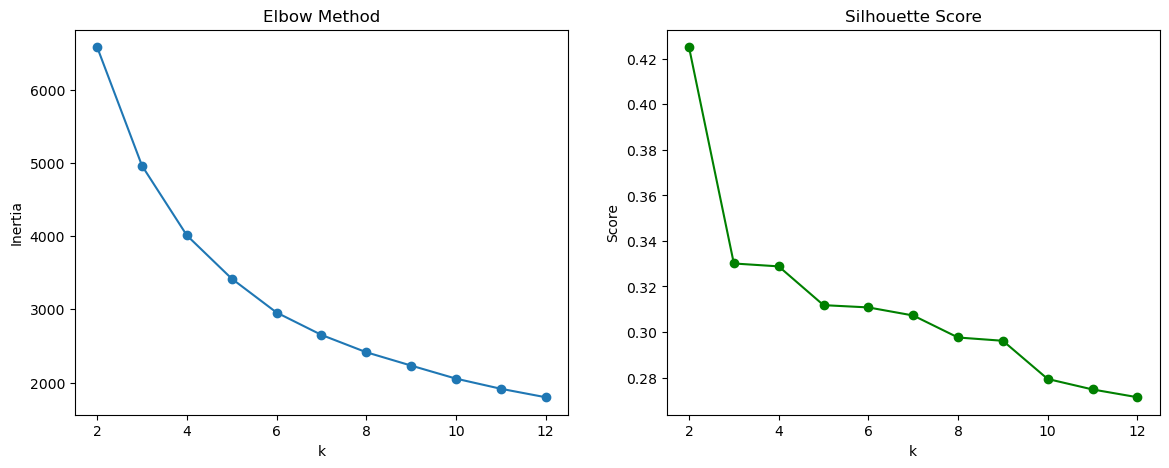

In [32]:
inertias = []
silhouettes = []
k_range = range(2, 13) # loop through different k-values to determine most optimal

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_data)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(scaled_data, labels))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(k_range, inertias, marker="o")
ax[0].set_title("Elbow Method"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")
ax[1].plot(k_range, silhouettes, marker="o", color="green")
ax[1].set_title("Silhouette Score"); ax[1].set_xlabel("k"); ax[1].set_ylabel("Score")
plt.show()


In [33]:
for k, s in zip(k_range, silhouettes):
    print(f"k={k}: silhouette={s:.4f}")


k=2: silhouette=0.4251
k=3: silhouette=0.3301
k=4: silhouette=0.3288
k=5: silhouette=0.3118
k=6: silhouette=0.3108
k=7: silhouette=0.3073
k=8: silhouette=0.2976
k=9: silhouette=0.2962
k=10: silhouette=0.2794
k=11: silhouette=0.2748
k=12: silhouette=0.2714


The visualizations above show that **k = 4** should be the number of clusters.
- The inertia curve bends around 3-4 and starts stabilizing after 4. By the elbow method, it is safe to assume that k = 4.
  
- The silhouete score plateaus at around k = 3 and k = 4 with minimal difference, before dropping at values of k after 4. Although it is highest at k = 2, having only 2 clusters would be insufficent, hence the local maximum at k = 4 suffices.   
  
- Since k = 3 and k = 4 are statistically indistinguishable based on silhouette score, the choice is made on interpretability. Four clusters gives more actionable business insight than three while retaining a strong silhouette score.  
  

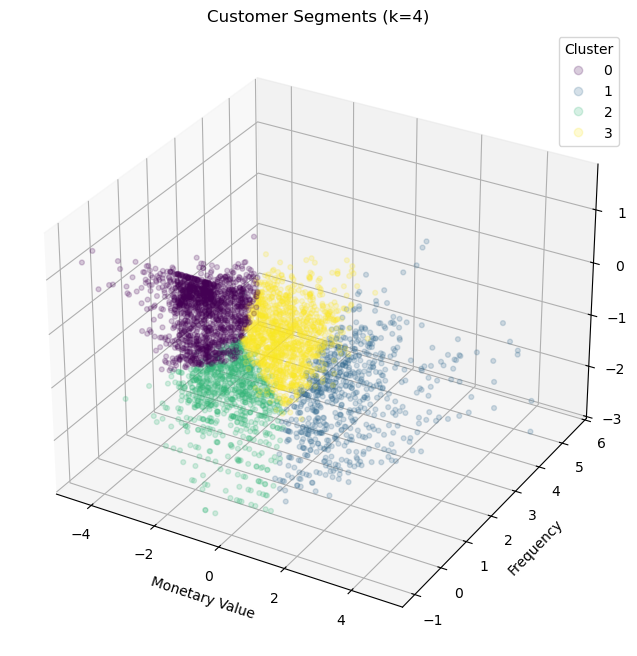

In [ ]:
# fit final model with chosen k
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_data)

agg_df["Cluster"] = cluster_labels
scaled_data_df["Cluster"] = cluster_labels

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(
    scaled_data_df["MonetaryValue"],
    scaled_data_df["Frequency"],
    scaled_data_df["Recency"],
    c=cluster_labels,
    cmap="viridis", 
    alpha=0.2, s=12,
)

ax.set_xlabel("Monetary Value")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
ax.set_title("Customer Segments (k=4)")

ax.legend(*scatter.legend_elements(), title="Cluster")

plt.show()


## Cluster Analysis

In [35]:
profile = agg_df.groupby("Cluster").agg(
    Recency_mean   = ("Recency", "mean"),
    Frequency_mean = ("Frequency", "mean"),
    Monetary_mean  = ("MonetaryValue", "mean"),
    Recency_median   = ("Recency", "median"),
    Frequency_median = ("Frequency", "median"),
    Monetary_median  = ("MonetaryValue", "median"),
    Count = ("Customer ID", "count"),
)
profile["Pct"] = (profile["Count"] / profile["Count"].sum() * 100).round(1)
profile


,Recency_mean,Frequency_mean,Monetary_mean,Recency_median,Frequency_median,Monetary_median,Count,Pct
Cluster,,,,,,,,
0,182.316872,1.320302,320.360837,178.0,1.0,267.415,1458,34.0
1,11.375907,14.226415,7827.827910,7.0,10.0,3757.920,689,16.1
2,21.863892,1.985377,530.470720,20.0,2.0,462.180,889,20.7
3,72.554844,4.382706,1847.553603,57.0,4.0,1397.590,1249,29.1


In [36]:
overall = agg_df[["Recency", "Frequency", "MonetaryValue"]].mean()
relative = agg_df.groupby("Cluster")[["Recency", "Frequency", "MonetaryValue"]].mean() / overall
relative.round(2)


,Recency,Frequency,MonetaryValue
Cluster,,,
0,2.04,0.30,0.16
1,0.13,3.21,3.88
2,0.24,0.45,0.26
3,0.81,0.99,0.92


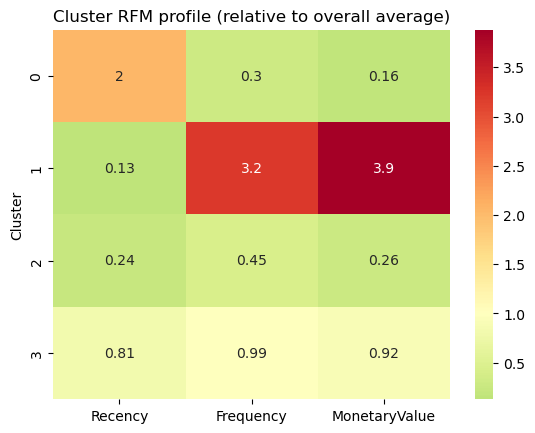

In [37]:
import seaborn as sns
sns.heatmap(relative, annot=True, cmap="RdYlGn_r", center=1.0)
plt.title("Cluster RFM profile (relative to overall average)")
plt.show()


- Cluster 0 (Inactive): 2.0 receny (bought long ago), 0.3 frequency (rare buyer), 0.16 monetary (low value). These are the customers that rarely buys, spends a little amount, and haven't been back since a long period of time.  

- Cluster 1 (MVPs):  Very low recency and very high frequency & monetary value. This is the segment that represents the "best customers", and are must-keep as they are the highest and most frequent spenders.

- Cluster 2  (Newcomers): 0.24 recency shows that they have bought very recently but low frequency and monetary value implies that they haven't bought often yet. These are the new and promising customers that are worth maintaining.  

- Cluster 3 (Regulars): Every value is right around 1.0. This is the mainstream, middle customers that represent the base average.

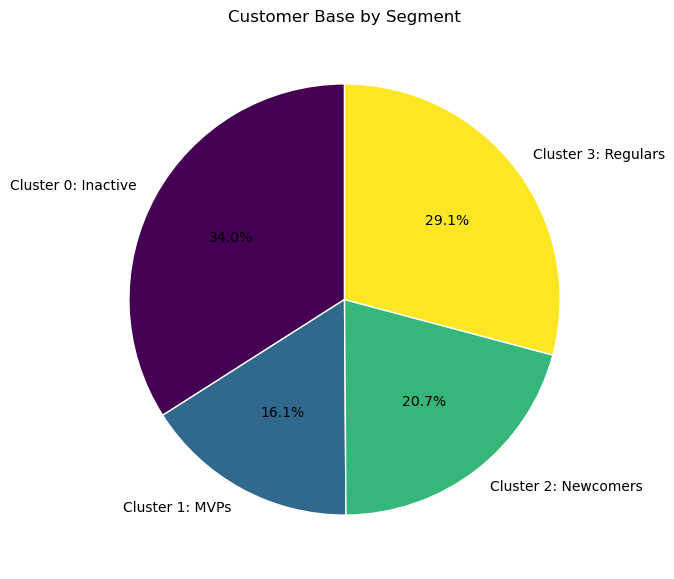

In [39]:
cluster_counts = agg_df["Cluster"].value_counts().sort_index()

labels = {
    0: "Cluster 0: Inactive",
    1: "Cluster 1: MVPs",
    2: "Cluster 2: Newcomers",
    3: "Cluster 3: Regulars",
}

n_clusters = len(cluster_counts)
cluster_colors = [plt.cm.viridis(i / (n_clusters - 1)) for i in range(n_clusters)]

plt.figure(figsize=(7, 7))
plt.pie(
    cluster_counts,
    labels=[labels[i] for i in cluster_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    colors=cluster_colors,
    wedgeprops={"edgecolor": "white"},
)
plt.title("Customer Base by Segment")
plt.show()


## Business Recommendations

Applying K-Means with k = 4 to the log-transformed and standardised RFM features produced four distinct customer segments. 

| Cluster | Segment | Share | Avg. Recency | Avg. Frequency | Avg. Monetary | Recommended action |
|---|---|---|---|---|---|---|
| 1 | MVPs | 16.1% | 11 days | 14.2 | £7,828 | Retain and reward. Prioritise loyalty benefits, early access, and dedicated account management. The segment is small but deals for a disproportionate share of revenue, so retention is the primary objective. |
| 3 | Regulars | 29.1% | 73 days | 4.4 | £1,848 | Develop and grow. Use targeted incentives to raise purchase frequency, with the aim of progressing these customers toward the MVP segment. |
| 2 | Newcomers | 20.7% | 22 days | 2.0 | £530 | Nurture and onboard. Recent first purchases indicate potential, offers should be used to develop a repeating purchase habit. |
| 0 | Inactive | 34.0% | 182 days | 1.3 | £320 | Re-engage selectively. This is the largest but least valuable segment. Low-cost campaigns are appropriate, but marketing spend should be at a limit given the low expected return. |




### Key findings

- Revenue is highly concentrated. The MVP segment represents only 16.1% of customers yet records the highest average spend (£7,828) and frequency (14.2 orders), confirming the commercial value of retaining a relatively small group of high-value customers.

- The largest segment is the least profitable. Inactive customers account for 34.0% of the base but average only £320 in spend and have not purchased in approximately six months, indicating a substantial pool of lapsed or one-off buyers.

- Recency distinguishes comparable-value segments. The Newcomers and Inactive segments have similar frequency and monetary profiles but are separated by recency, showing that recency is the decisive variable for identifying customers worth re-investing in versus those likely already lost.

### Limitations and further work

- The analysis covers a single 12-month period (December 2009 – December 2010).

- High-value customers were retained and handled through log-transformation rather than removal. An alternative approach would be to model these customers separately.

- Future work could incorporate product-category preferences or customer tenure to refine the segments and support more precisely targeted campaigns.